# ERA5 Verification for the 2011 Super Outbreak

This notebook will use ERA5 data to see how the 2011 Super Outbreak was handled for reanalysis.

Specifically, this notebook will look at CAPE and 2m temperature.

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import datetime as dt
from metpy.units import units
import metpy.calc as mpcalc
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

Setting the dates of interest.

In [2]:
start_date = '20110425/00'
end_date = '20110428/00'

interval_hours = 12

interval_hours = dt.timedelta(hours=interval_hours)
sdate = dt.datetime.strptime(start_date,'%Y%m%d/%H')
edate = dt.datetime.strptime(end_date,'%Y%m%d/%H') + interval_hours

yyyymm = dt.datetime.strftime(sdate,'%Y%m')

Opening the dataset.

In [3]:
ds = xr.open_dataset(
  'https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr', 
  chunks={}, storage_options={"client_kwargs":{"trust_env":True}}, consolidated=True, engine="zarr"
  )
data = ds.sel(valid_time=slice(sdate, edate))

Setting up the areal extent.

In [4]:
lonW = -105
lonE = -75
latS = 28
latN = 42
cLat, cLon = (latS + latN)/2, (lonW + lonE)/2

# converting to conventional longitude format
if (lonW < 0 ):
    lonW = lonW + 360
if (lonE < 0 ):
    lonE = lonE + 360
    
expand = 1
latRange = np.arange(latS - expand,latN + expand,.25)
lonRange = np.arange((lonW - expand),(lonE + expand),.25)

# further limiting our data set to contain just the desired latitude and longitude ranges
data = data.sel(latitude=latRange,longitude=lonRange)
data

<xarray.Dataset> Size: 357MB
Dimensions:     (valid_time: 85, latitude: 64, longitude: 128)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 680B 2011-04-25 ... 2011-04-28T12...
  * latitude    (latitude) float64 512B 27.0 27.25 27.5 ... 42.25 42.5 42.75
  * longitude   (longitude) float64 1kB 254.0 254.2 254.5 ... 285.2 285.5 285.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/128)
    alnid       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3MB dask.array<chunksize=(85, 64, 62), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Extracting the variables of interest.

In [5]:
cape = data['cape']
temp = data['t2m']
temp = (temp - 273.15) * 9/5 + 32
lats = temp.latitude
lons = temp.longitude

Plotting the map!

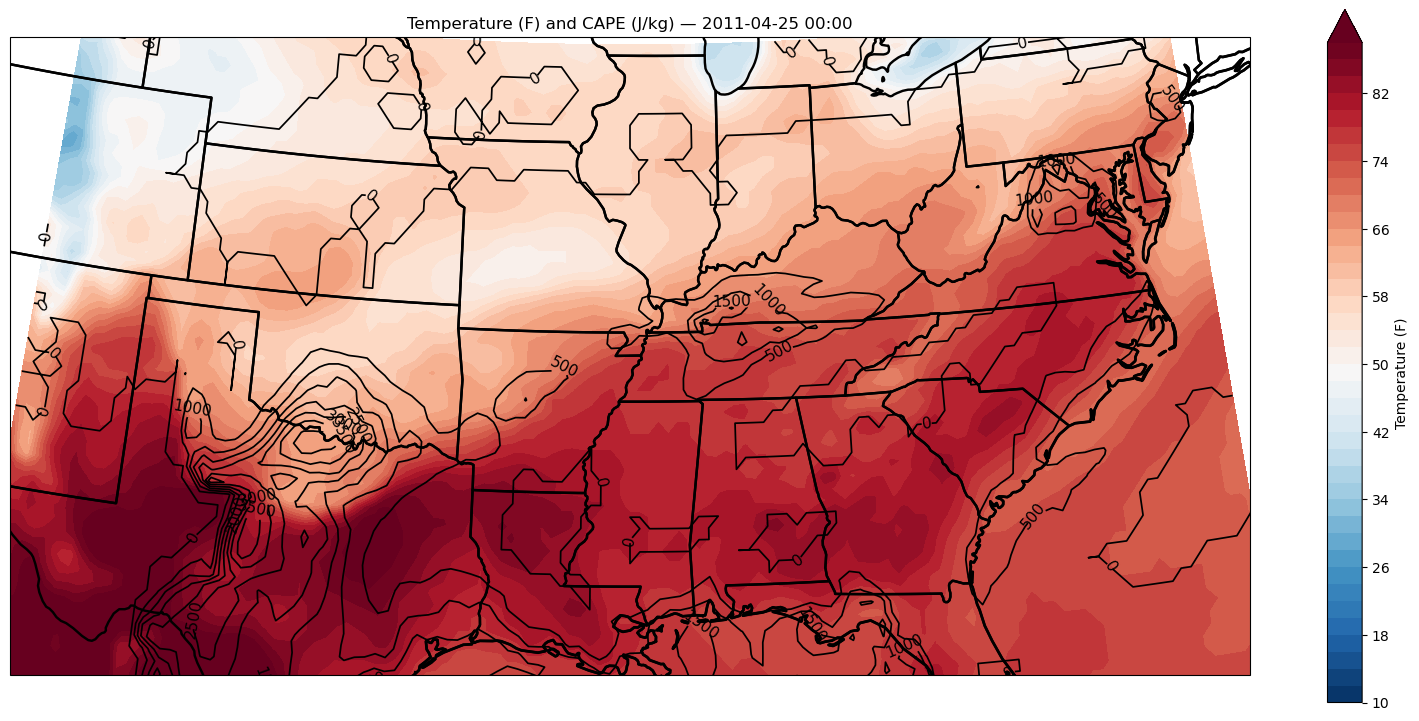

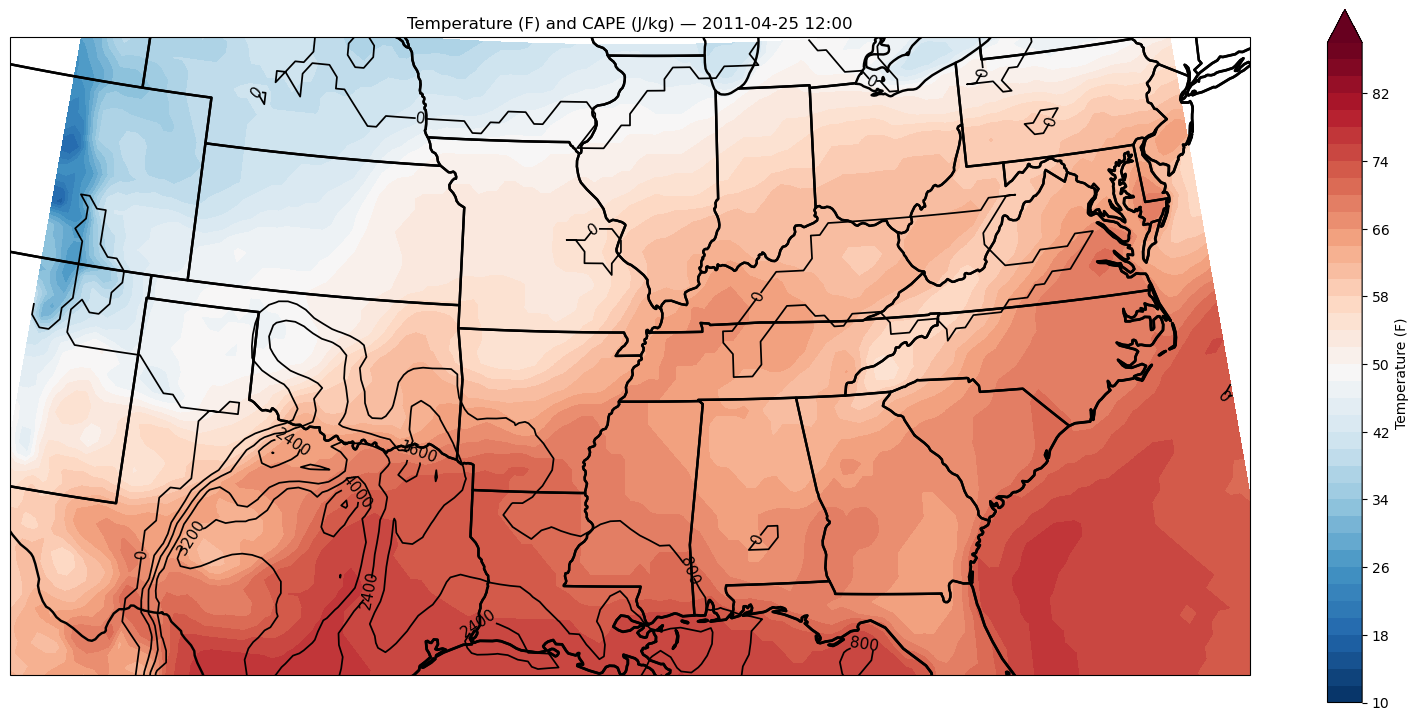

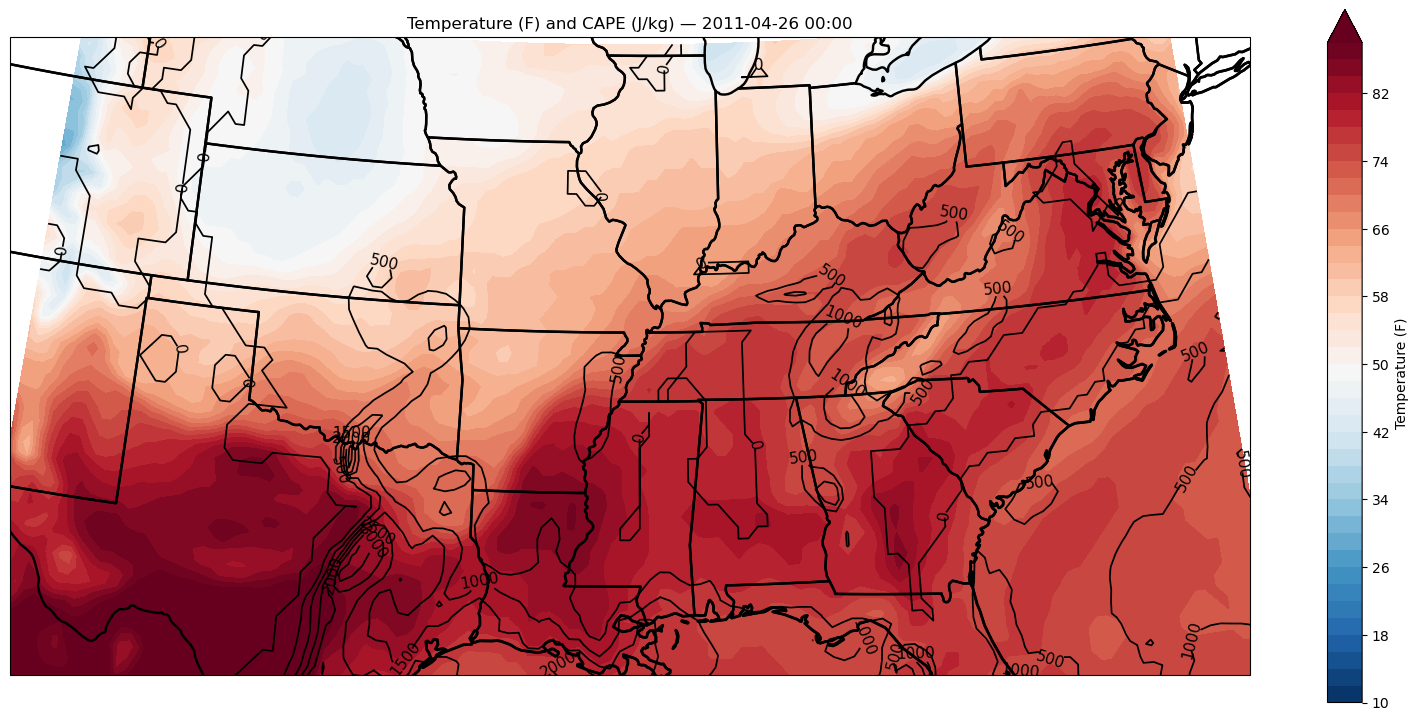

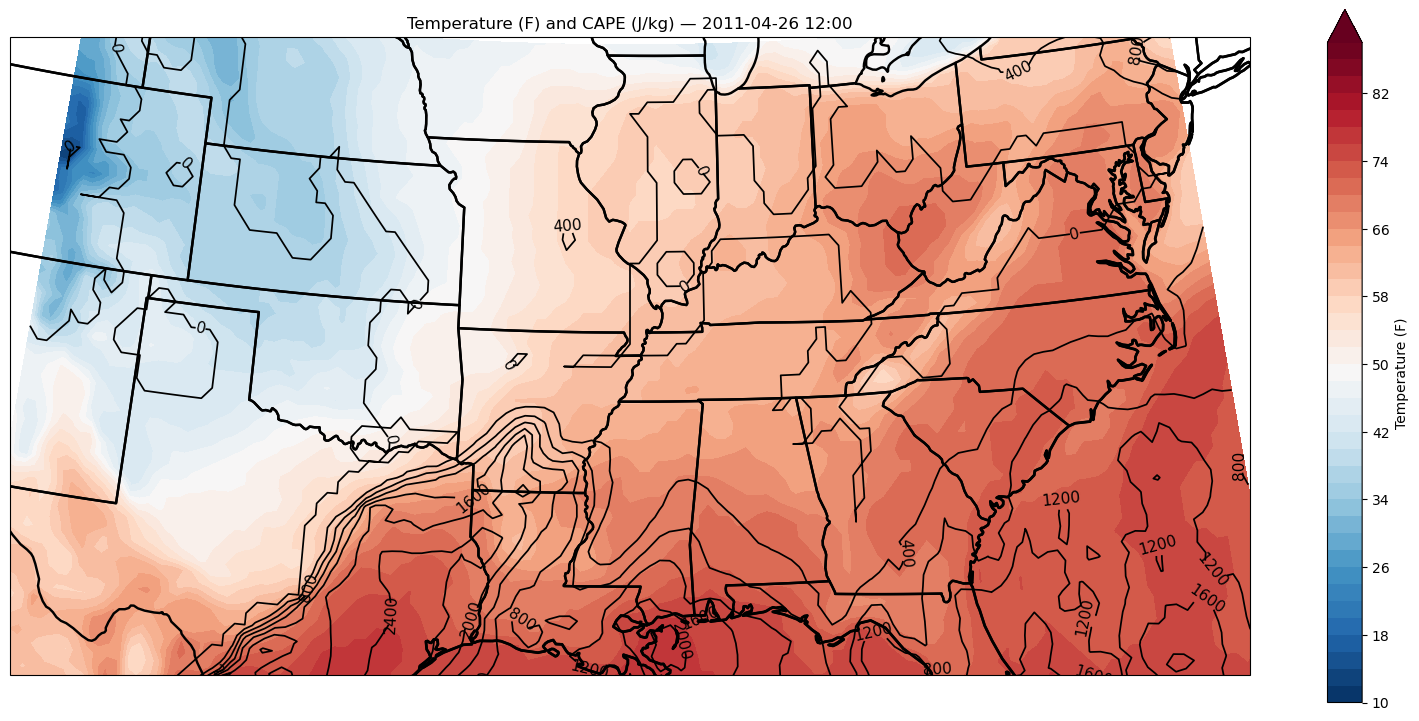

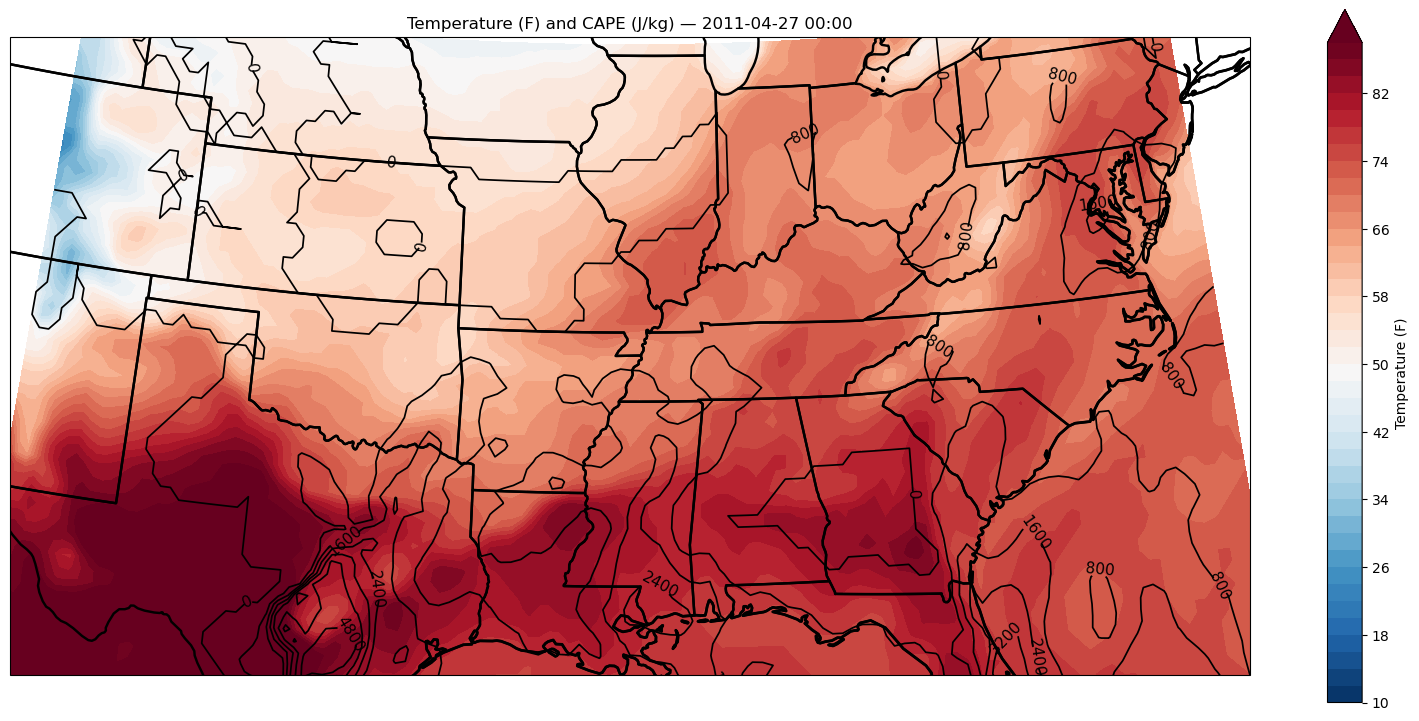

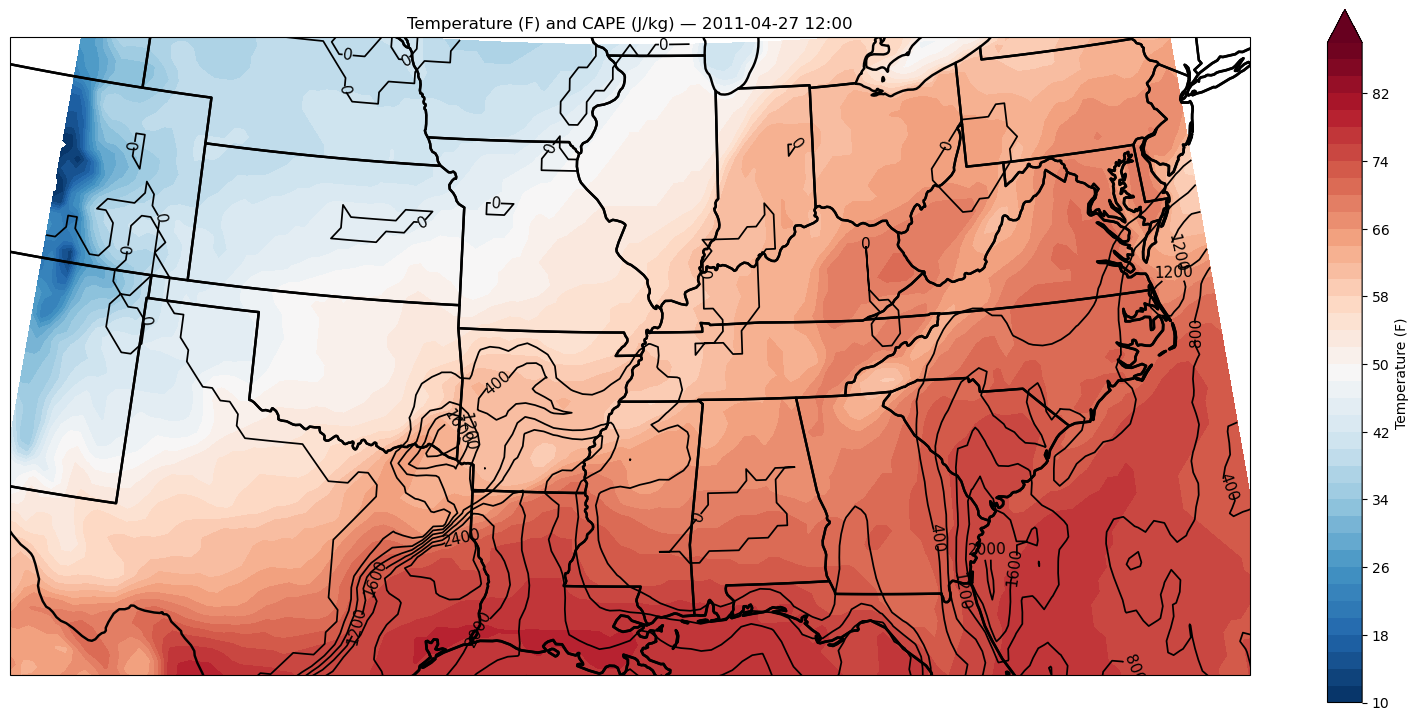

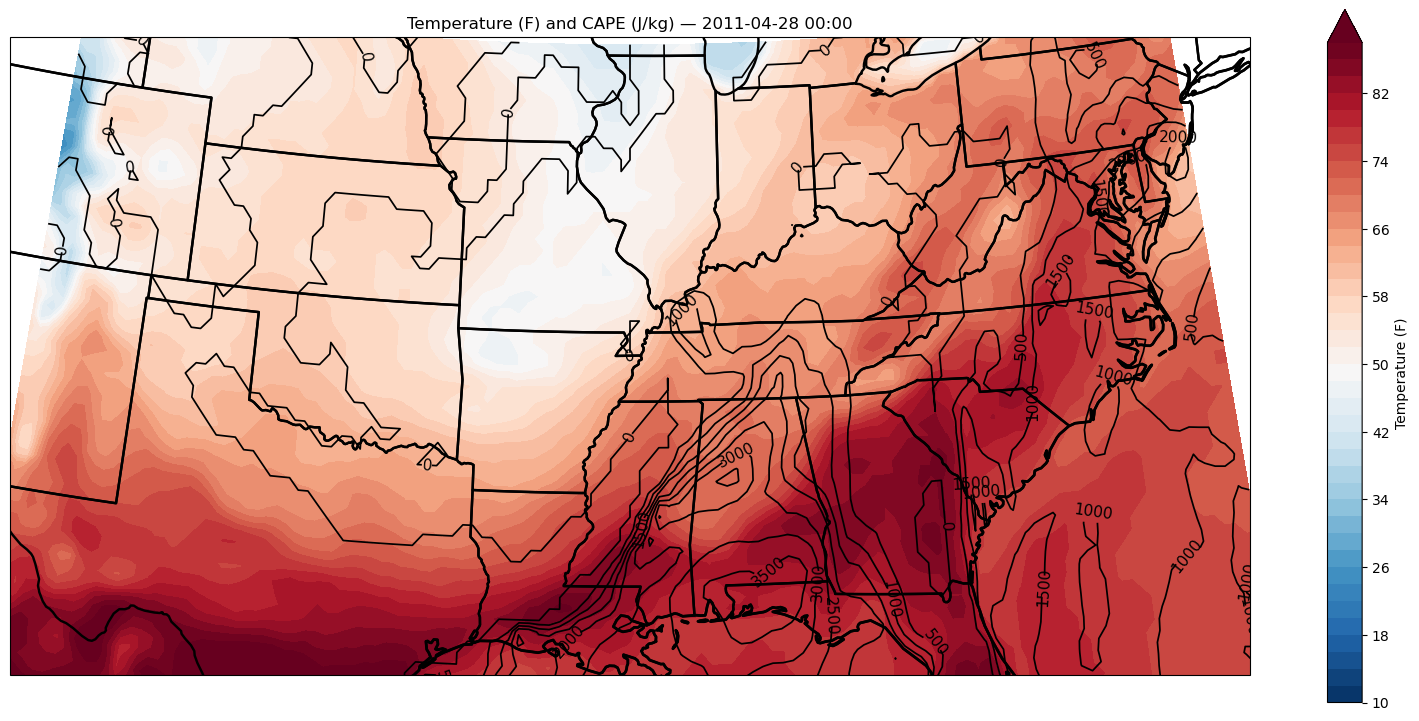

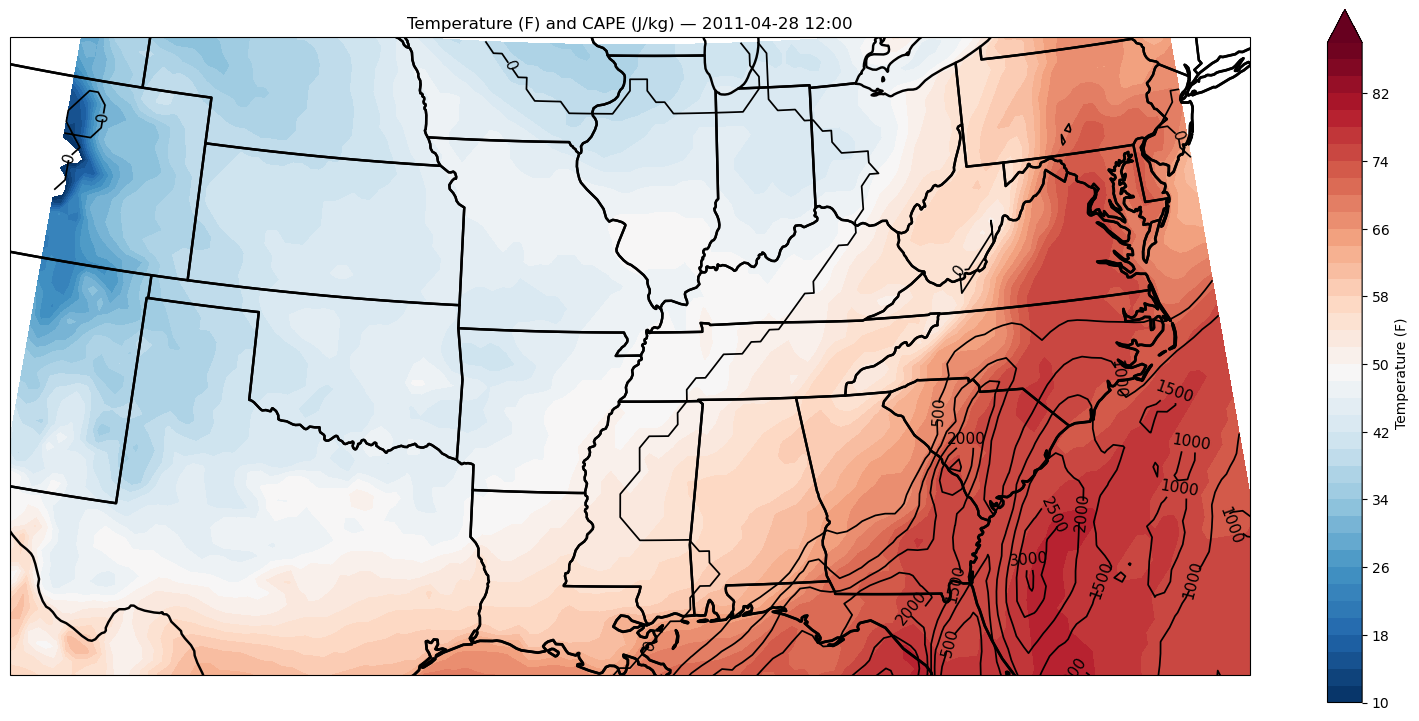

In [6]:
proj_map = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)
proj_data = ccrs.PlateCarree() 
res = '50m'

# some help making the loop skip every 12 hours with chatgpt!
for t in cape.valid_time.sel(valid_time=cape.valid_time.dt.hour.isin([0, 12])):
    fig, ax = plt.subplots(subplot_kw={'projection': proj_map}, figsize=(20,15))
    ax.set_extent([lonW, lonE, latS, latN])
    ax.add_feature(cfeature.COASTLINE.with_scale(res),linewidth=2)
    ax.add_feature(cfeature.STATES.with_scale(res),linewidth=1.75)

    CL = ax.contour(lons, lats, cape.sel(valid_time=t), transform=proj_data,
                    linewidths=1.25, colors='black')
    tint = np.arange(10,90,2)
    CF = ax.contourf(lons, lats, temp.sel(valid_time=t), levels=tint, transform=proj_data,
                     cmap='RdBu_r', extend='max')
    cbar = fig.colorbar(CF,shrink=0.6,label = 'Temperature (F)')
    clabel = ax.clabel(CL, inline_spacing=0.2, fontsize=11, fmt='%.0f')

    ax.set_title(f"Temperature (F) and CAPE (J/kg) — {t.dt.strftime('%Y-%m-%d %H:%M').item()}")
    plt.show()

Great! We have created a map centered over our area of interest, the southeast United States, and plotted the temperature in shading along with contour lines of the CAPE values. This allows us to get an understanding of the atmospheric environment that allowed for the 2011 Super Outbreak.

Next, we will take a look at how we can alter this notebook to create plots that allow us to examine the impacts of a lake effect snow event.